In [155]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler, StandardScaler

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
np.random.seed(42)          # cố định ngẫu nhiên -> kết quả tái lập được
print("Sẵn sàng.")

Sẵn sàng.


In [156]:
try:
    df = sns.load_dataset("titanic")
    print("Đã tải từ seaborn.")
except Exception:
    url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
    df = pd.read_csv(url)
    df.columns = [c.lower() for c in df.columns]
    print("Đã tải từ URL.")
df.head()

Đã tải từ seaborn.


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [157]:
# TODO 1a: in tỷ lệ missing của tất cả các cột
df_missing = df.isnull().mean() * 100
print(df_missing)

# TODO 1b: bỏ các cột rò rỉ/dư thừa, gán lại vào biến df
leaky = ['alive', 'who', 'adult_male', 'class', 'deck', 'embark_town', 'alone']     
df = df.drop(columns=leaky)

print("Các cột còn lại:", list(df.columns))

survived        0.000000
pclass          0.000000
sex             0.000000
age            19.865320
sibsp           0.000000
parch           0.000000
fare            0.000000
embarked        0.224467
class           0.000000
who             0.000000
adult_male      0.000000
deck           77.216611
embark_town     0.224467
alive           0.000000
alone           0.000000
dtype: float64
Các cột còn lại: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']


In [158]:
# TODO 2: shape, info, describe
rows = df.shape[0]
cols = df.shape[1]
print(f"Shape: {rows} rows, {cols} columns")
df.info()
df.describe()

Shape: 891 rows, 8 columns
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   sex       891 non-null    str    
 3   age       714 non-null    float64
 4   sibsp     891 non-null    int64  
 5   parch     891 non-null    int64  
 6   fare      891 non-null    float64
 7   embarked  889 non-null    str    
dtypes: float64(2), int64(4), str(2)
memory usage: 55.8 KB


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [159]:
df.describe(include="object")

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_11036\702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,sex,embarked
count,891,889
unique,2,3
top,male,S
freq,577,644


In [160]:
# TODO 3: bảng missing (count + %)
missing_count = df.isnull().sum()
missing_percent = df.isnull().mean() * 100
missing_table = pd.DataFrame({
    'Missing Count' : missing_count,
    'Missing Percent' : missing_percent   
})
display(missing_table)

,Missing Count,Missing Percent
survived,0,0.000000
pclass,0,0.000000
sex,0,0.000000
age,177,19.865320
sibsp,0,0.000000
parch,0,0.000000
fare,0,0.000000
embarked,2,0.224467


In [161]:
median = df['age'].median()
df['age'] = df['age'].fillna(median)

mode = df['embarked'].mode()[0]
df['embarked'] = df['embarked'].fillna(mode)

df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.361582,0.523008,0.381594,32.204208
std,0.486592,0.836071,13.019697,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [162]:
# TODO 4: đếm outlier theo IQR và Z-score cho 'age' và 'fare'
def dem_outlier_iqr(s):
     Q1 = df[s].quantile(0.25)
     Q3 = df[s].quantile(0.75)
     IQR = Q3 - Q1
     lower_pound = Q1 - 1.5*IQR
     upper_pound = Q3 + 1.5*IQR
     return len(df[(df[s] < lower_pound ) | (df[s] > upper_pound)])  # trả về số lượng outlier theo IQR

from scipy import stats

def dem_outlier_zscore(s, nguong=3.0):
     z_scores = stats.zscore(df[s])
     return len(df[abs(z_scores) > nguong]) # trả về số lượng outlier theo Z-score

for col in ["age", "fare"]:
    outlier_iqr = dem_outlier_iqr(col)
    outlier_zscore = dem_outlier_zscore(col)
    print(f"Outliers in '{col}' using IQR: {outlier_iqr}")
    print(f"Outliers in '{col}' using Z-score: {outlier_zscore}")

Outliers in 'age' using IQR: 66
Outliers in 'age' using Z-score: 7
Outliers in 'fare' using IQR: 116
Outliers in 'fare' using Z-score: 20


In [163]:
def outlier_iqr(s):
     Q1 = df[s].quantile(0.25)
     Q3 = df[s].quantile(0.75)
     IQR = Q3 - Q1
     lower_pound = Q1 - 1.5*IQR
     upper_pound = Q3 + 1.5*IQR
     return df[(df[s] < lower_pound ) | (df[s] > upper_pound)]

outlier_iqr = outlier_iqr('fare')
fare_outliers_table = outlier_iqr[['fare', 'pclass']]
display(fare_outliers_table)
print(outlier_iqr['pclass'].value_counts())

,fare,pclass
1,71.2833,1
27,263.0000,1
31,146.5208,1
34,82.1708,1
52,76.7292,1
...,...,...
846,69.5500,3
849,89.1042,1
856,164.8667,1
863,69.5500,3


pclass
1    104
3      7
2      5
Name: count, dtype: int64


In [164]:
print(df.columns)

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked'],
      dtype='str')


In [165]:
df = pd.get_dummies(df, columns=['sex', 'embarked'], drop_first=True, dtype=int)

In [166]:
family_size = df['sibsp'] + df['parch'] + 1
df['family_size'] = family_size
df = df.drop(columns=['sibsp', 'parch'])

In [167]:
df.head()

,survived,pclass,age,fare,sex_male,embarked_Q,embarked_S,family_size
0,0,3,22.0,7.2500,1,0,1,2
1,1,1,38.0,71.2833,0,0,0,2
2,1,3,26.0,7.9250,0,0,1,1
3,1,1,35.0,53.1000,0,0,1,2
4,0,3,35.0,8.0500,1,0,1,1


In [168]:
# TODO 3: Chia tập và Scale dữ liệu
X = df.drop(columns=['survived'])
y = df['survived']

# X_train, X_test, y_train, y_test = train_test_split(...)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [169]:
num_cols = [ "age", "fare", "sex_male", "embarked_Q", "embarked_S", "family_size"]
ord_cols = ["pclass"]

# TODO 7: xây pipeline cho biến số và biến phân loại
pipe_so  = Pipeline([
    ("imputer", SimpleImputer(strategy='median')),
    ("scaler",  RobustScaler()),
])

preprocess = ColumnTransformer([
    ("num", pipe_so,  num_cols),
    ("ord", "passthrough", ord_cols),
])

preprocess.fit(X_train)               # fit CHỈ trên train
X_train_t = preprocess.transform(X_train)
X_test_t = preprocess.transform(X_test)

print(X_train_t.shape, list(preprocess.get_feature_names_out()))

(712, 7) ['num__age', 'num__fare', 'num__sex_male', 'num__embarked_Q', 'num__embarked_S', 'num__family_size', 'ord__pclass']


**Huấn luyện Logistic Regression**

1. Accuracy (Độ chính xác tổng thể): 0.8045 (80.45%)
2. Precision (Độ chính xác khi dự đoán Sống sót): 0.7826
3. Recall (Tỷ lệ tìm ra người Sống sót)         : 0.7297
4. F1-score (Trung bình điều hòa của P & R)     : 0.7552
Confusion matrix (Logistic Regression)
[[90 15]
 [20 54]]


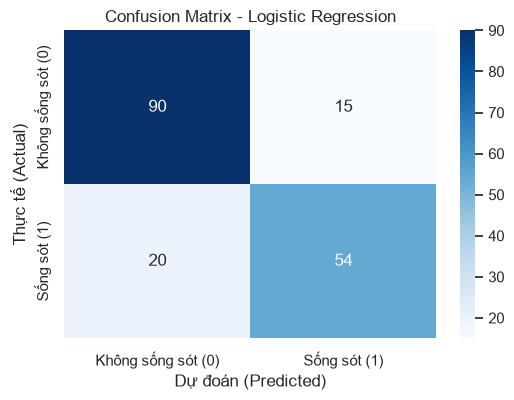

In [170]:
log_model = LogisticRegression()
log_model.fit(X_train_t, y_train)

y_pred_log =log_model.predict(X_test_t)

accuracy_log = accuracy_score(y_test, y_pred_log)
precision_log = precision_score(y_test, y_pred_log)
recall_log = recall_score(y_test, y_pred_log)
f1_log = f1_score(y_test, y_pred_log)
rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_log))
r2_log = r2_score(y_test, y_pred_log)

print(f"1. Accuracy (Độ chính xác tổng thể): {accuracy_log:.4f} ({accuracy_log*100:.2f}%)")
print(f"2. Precision (Độ chính xác khi dự đoán Sống sót): {precision_log:.4f}")
print(f"3. Recall (Tỷ lệ tìm ra người Sống sót)         : {recall_log:.4f}")
print(f"4. F1-score (Trung bình điều hòa của P & R)     : {f1_log:.4f}")

print("Confusion matrix (Logistic Regression)")
conf_matrix_log = confusion_matrix(y_test, y_pred_log)
print(conf_matrix_log)

plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_log, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Không sống sót (0)', 'Sống sót (1)'], 
            yticklabels=['Không sống sót (0)', 'Sống sót (1)'])
plt.xlabel('Dự đoán (Predicted)')
plt.ylabel('Thực tế (Actual)')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()


# Bài 2: Dry bean dataset

In [171]:
train_df = pd.read_csv('Dry_Bean_Dataset/dry_bean_train.csv')      
test_df = pd.read_csv('Dry_Bean_Dataset/dry_bean_test.csv')

X_train = train_df.drop(columns=['class'])
y_train = train_df['class']
X_test = test_df.drop(columns=['class'])
y_test = test_df['class']

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

logr_model = LogisticRegression(max_iter=1000)
logr_model.fit(X_train_scaled, y_train)
y_pred_logr = logr_model.predict(X_test_scaled)

print(classification_report(y_test, y_pred_logr))


              precision    recall  f1-score   support

    BARBUNYA       0.93      0.89      0.91       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.91      0.94      0.93       326
    DERMASON       0.93      0.91      0.92       709
       HOROZ       0.96      0.94      0.95       372
       SEKER       0.93      0.94      0.94       406
        SIRA       0.86      0.88      0.87       527

    accuracy                           0.92      2709
   macro avg       0.93      0.93      0.93      2709
weighted avg       0.92      0.92      0.92      2709



Confusion matrix (Logistic Regression)
[[90 15]
 [20 54]]


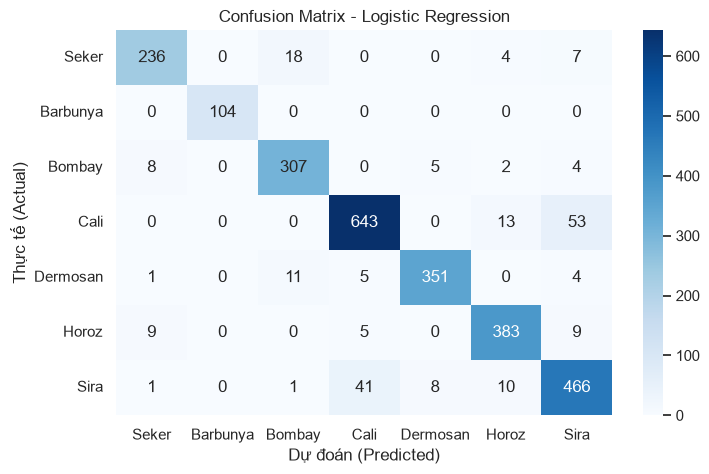

In [172]:
print("Confusion matrix (Logistic Regression)")
conf_matrix_logr = confusion_matrix(y_test, y_pred_logr)
print(conf_matrix_log)

plt.figure(figsize=(8, 5))
sns.heatmap(conf_matrix_logr, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Seker', 'Barbunya', 'Bombay', 'Cali', 'Dermosan', 'Horoz', 'Sira'], 
            yticklabels=['Seker', 'Barbunya', 'Bombay', 'Cali', 'Dermosan', 'Horoz', 'Sira'])
plt.xlabel('Dự đoán (Predicted)')
plt.ylabel('Thực tế (Actual)')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

**KNN**

In [173]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)
y_pred_knn = knn_model.predict(X_test_scaled)
print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

    BARBUNYA       0.93      0.88      0.90       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.90      0.95      0.92       326
    DERMASON       0.92      0.91      0.91       709
       HOROZ       0.96      0.93      0.95       372
       SEKER       0.95      0.94      0.94       406
        SIRA       0.85      0.87      0.86       527

    accuracy                           0.92      2709
   macro avg       0.93      0.93      0.93      2709
weighted avg       0.92      0.92      0.92      2709



Confusion matrix (KNN)
[[232   0  21   0   1   3   8]
 [  0 104   0   0   0   0   0]
 [  8   0 309   0   5   2   2]
 [  0   0   0 647   0  10  52]
 [  0   0  13   4 347   0   8]
 [  6   0   1   7   0 380  12]
 [  3   0   0  49   8   6 461]]


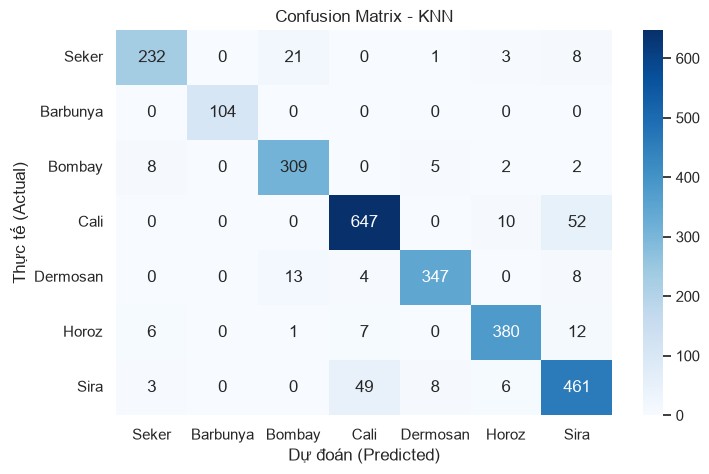

In [174]:
print("Confusion matrix (KNN)")
conf_matrix_knn = confusion_matrix(y_test, y_pred_knn)
print(conf_matrix_knn)

plt.figure(figsize=(8, 5))
sns.heatmap(conf_matrix_knn, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Seker', 'Barbunya', 'Bombay', 'Cali', 'Dermosan', 'Horoz', 'Sira'], 
            yticklabels=['Seker', 'Barbunya', 'Bombay', 'Cali', 'Dermosan', 'Horoz', 'Sira'])
plt.xlabel('Dự đoán (Predicted)')
plt.ylabel('Thực tế (Actual)')
plt.title('Confusion Matrix - KNN')
plt.show()

